In [1]:
import pandas as pd

df = pd.read_csv("../data/cleaned_data02.csv")

df.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment
0,33554,53,100473.211709,63,121.430565,0.817268,66.820403,0.117256,0.023144,77.298393,2.0,Card,Semi-Urban,Occasional
1,9428,54,54730.644845,67,572.552674,3.176551,137.087449,0.261647,0.429054,92.132565,2.0,Wallet,Urban,Occasional
2,200,44,58268.121079,57,266.593896,2.713168,71.796888,0.284785,0.011854,155.194768,1.0,UPI,Rural,Occasional
3,12448,54,64829.795654,40,691.452358,5.553977,105.501185,0.104832,0.399686,113.917756,0.0,Wallet,Rural,High_Value
4,39490,28,27431.467873,15,832.664792,1.348389,354.568534,0.409204,0.039517,50.123656,1.0,Card,Semi-Urban,Occasional


In [2]:
import pickle

with open("../data/processed_variables.pkl", "rb") as f:
    data = pickle.load(f)

df = data["df"]
numeric_columns = data["numeric_columns"]

In [3]:
df.isnull().sum()

customer_id              0
age                      0
annual_income            0
months_active            0
avg_monthly_spend        0
purchase_frequency       0
avg_order_value          0
discount_usage_rate      0
return_rate              0
browsing_time_minutes    0
support_interactions     0
payment_method           0
region                   0
customer_segment         0
dtype: int64

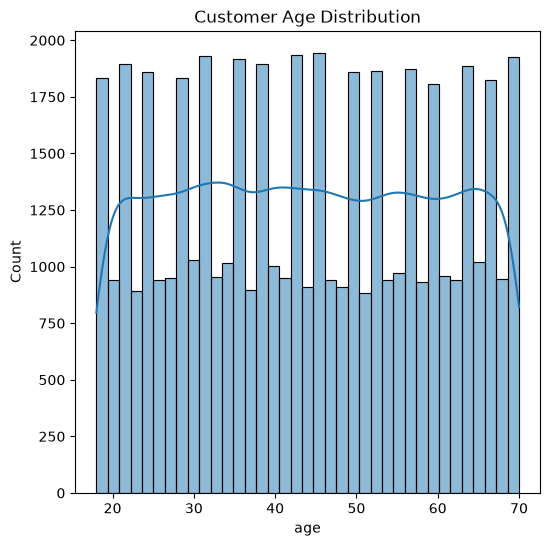

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))

sns.histplot(df['age'],kde=True)

plt.title('Customer Age Distribution')
plt.show()

In [5]:
# Key observations of the above graph
# The distribution is mostly symmetric and bell-shaped around the middle age range.
# Most customers are between about 25 and 55 years old.
# The highest concentration is around ages 35–45.
# There are fewer customers at the youngest ages (around 18–25) and older ages (above 60).
# The KDE curve smooths this pattern and confirms the peak is near the center of the distribution.

# Questions:
# What is the average customer age? -- 35 - 45
# Which age group dominates? 35 -45 
# Are there extreme ages? yes upto 70

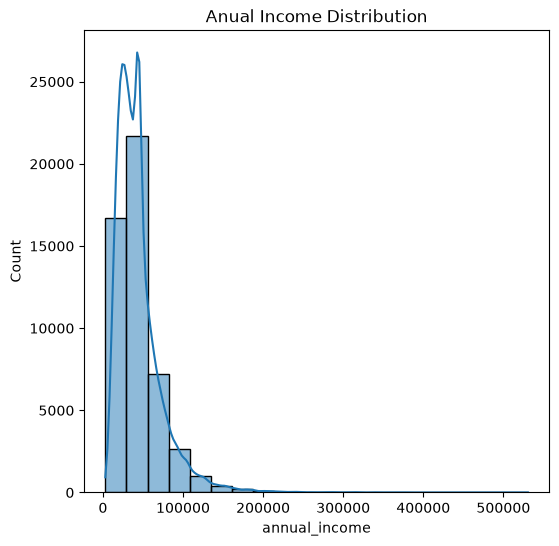

In [6]:
plt.figure(figsize=(6,6))
sns.histplot(df['annual_income'],kde=True,bins=20)
plt.title('Anual Income Distribution')
plt.show()

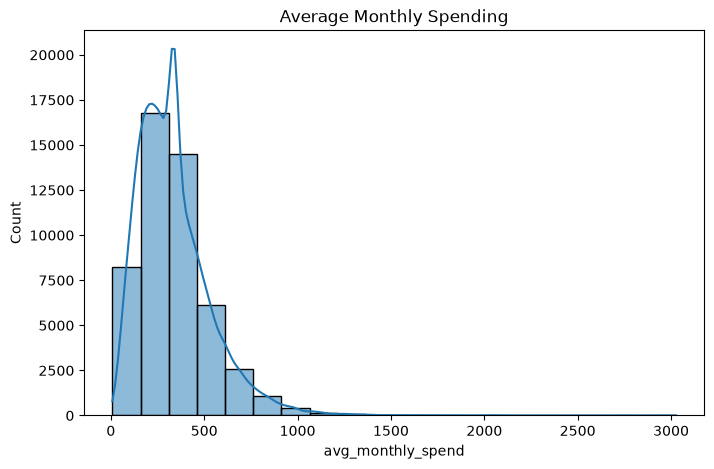

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df["avg_monthly_spend"], kde=True,bins=20)

plt.title("Average Monthly Spending")
plt.show()

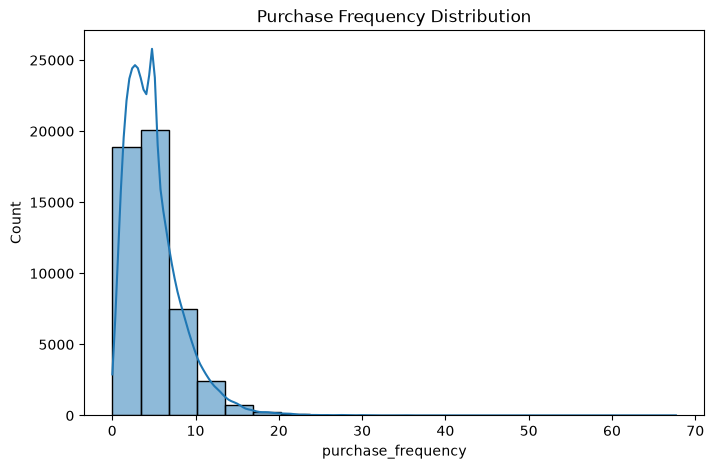

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["purchase_frequency"], kde=True,bins=20)

plt.title("Purchase Frequency Distribution")
plt.show()

categorical analyses

In [9]:
df["payment_method"].value_counts()

payment_method
Card      24953
UPI       14898
Wallet    10149
Name: count, dtype: int64

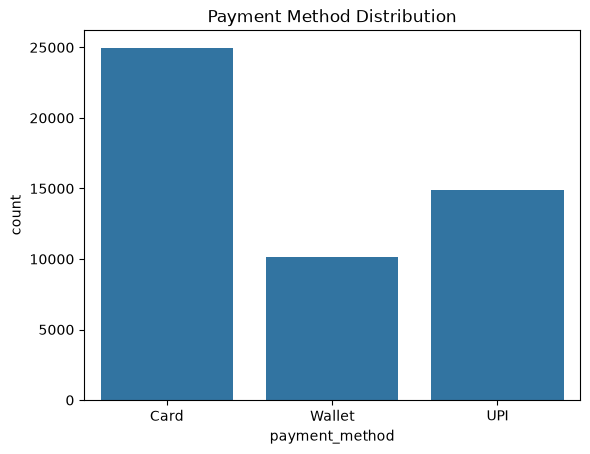

In [10]:
# Payment Method Distribution
sns.countplot(data=df, x="payment_method")

plt.title("Payment Method Distribution")
plt.show()

In [11]:
df['region'].value_counts()

region
Urban         24785
Semi-Urban    15212
Rural         10003
Name: count, dtype: int64

Text(0.5, 1.0, 'customer distribution by region')

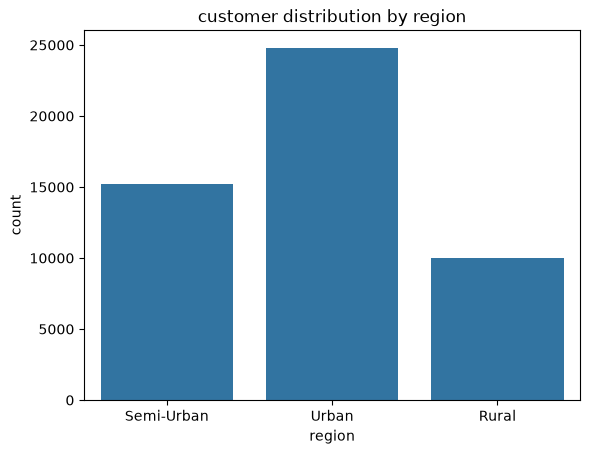

In [12]:
# Region Distribution
sns.countplot(data=df,x = 'region')
plt.title('customer distribution by region')

In [13]:
df["customer_segment"].value_counts()

customer_segment
Occasional    22109
Regular       13455
Loyal          9163
High_Value     5273
Name: count, dtype: int64

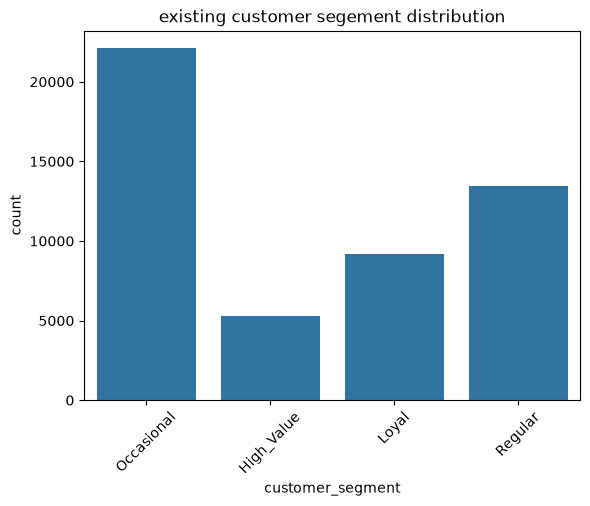

In [14]:
# Existing Customer Segment Distribution
sns.countplot(data = df,x='customer_segment')
plt.title('existing customer segement distribution')
plt.xticks(rotation = 45)
plt.show()

BIVARIATE ANALYSIS

Text(0.5, 1.0, 'income vs monthly spend')

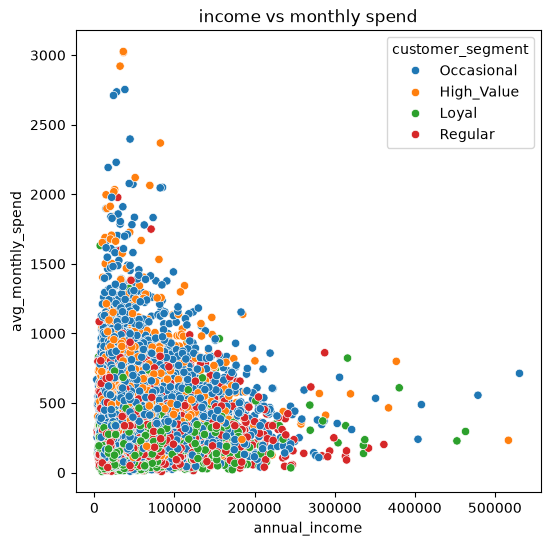

In [15]:
# Income vs Monthly Spending
plt.figure(figsize=(6,6))
sns.scatterplot(
    data = df,
    x = 'annual_income',
    y='avg_monthly_spend',
    hue='customer_segment'
)
plt.title('income vs monthly spend')

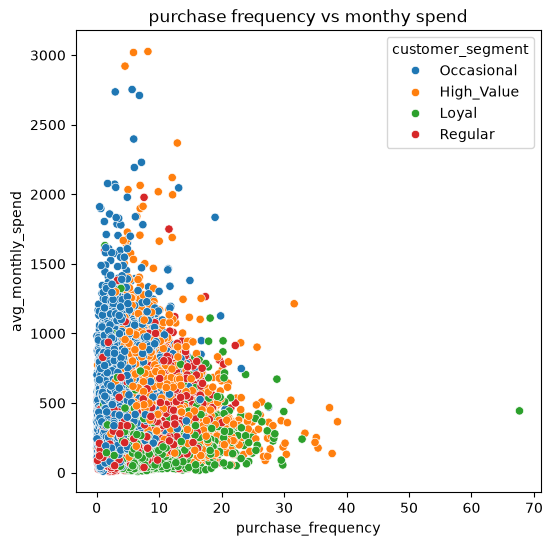

In [16]:
# Purchase Frequency vs Monthly Spending
plt.figure(figsize=(6,6))
sns.scatterplot(
    data = df,
    x='purchase_frequency',
    y='avg_monthly_spend',
    hue='customer_segment'
)
plt.title('purchase frequency vs monthy spend')
plt.show()

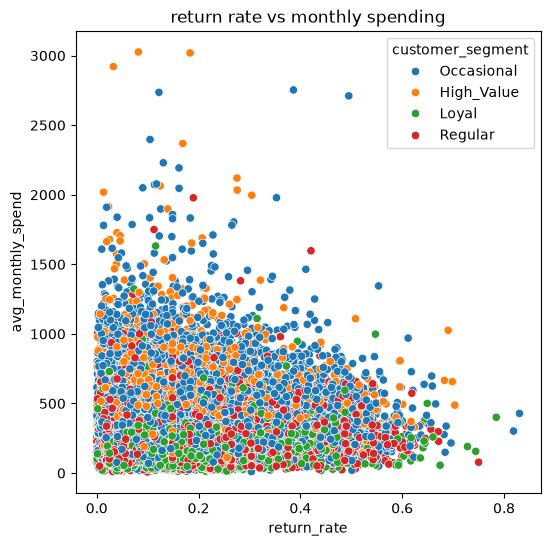

In [17]:
# Return Rate vs Monthly Spending
plt.figure(figsize=(6,6))

sns.scatterplot(
    data = df,
    x ='return_rate',
    y='avg_monthly_spend',
    hue='customer_segment'
)

plt.title('return rate vs monthly spending')
plt.show()

CORRELATION ANALYSIS

In [18]:
# numeric_columns = [
#     'age',
#     'annual_income',
#     'avg_monthly_spend',
#     'purchase_frequency',
#     'discount_usage_rate',
#     'return_rate',
#     'browsing_time_minutes',
#     'support_interactions'
# ]

In [19]:
corr = df[numeric_columns].corr()

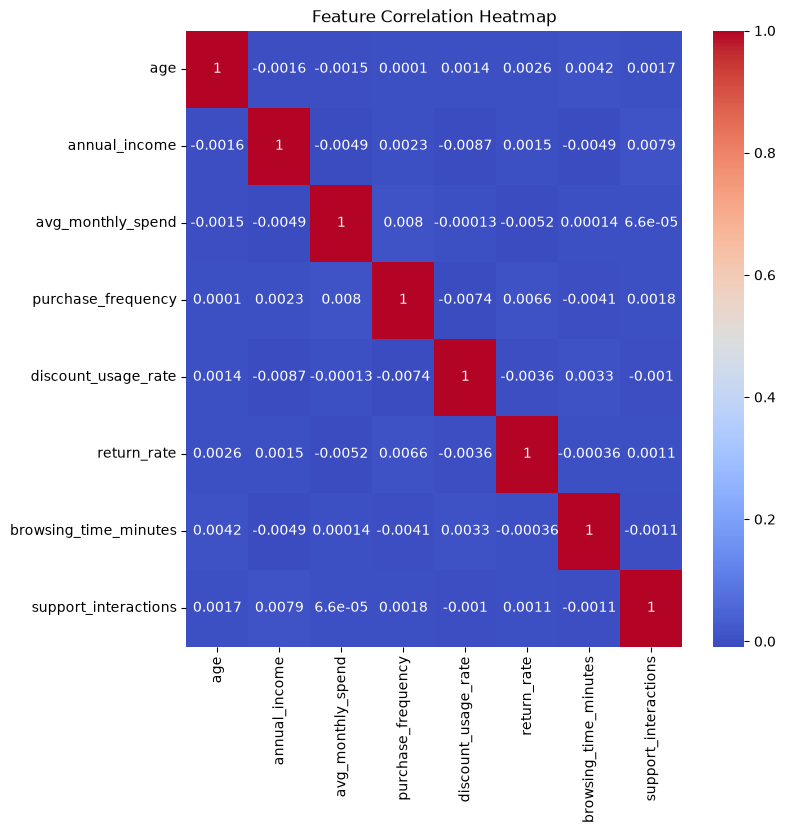

In [20]:
plt.figure(figsize=(8,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [21]:
# Important Questions

# Look for:

# Income vs Spending = -0.0049 not relate much
# Frequency vs Spending = 0.008 relate 
# Browsing Time vs Purchase Frequency = -0.0041 negative corellation
# Support Interactions vs Return Rate = 0.0011 positive corellation

In [22]:
df.to_csv('../data/analysed_data03.csv', index=False)